<a href="https://colab.research.google.com/github/AnkitaMondal17/crop_prediction/blob/main/crop_production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/crop_production.csv') # Assuming the file is directly in /content/
# Rename columns for easier access
df = df.rename(columns={
    'Cost of Cultivation (`/Hectare) A2+FL': 'Cost_Cult_A2_FL',
    'Cost of Cultivation (`/Hectare) C2': 'Cost_Cult_C2',
    'Cost of Production (`/Quintal) C2': 'Cost_Prod_C2',
    'Yield (Quintal/ Hectare) ': 'Yield' # Corrected with trailing space
})
print("DataFrame head after renaming:")
print(df.head())
print("DataFrame columns after renaming:")
print(df.columns)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DataFrame head after renaming:
    Crop           State  Cost_Cult_A2_FL  Cost_Cult_C2  Cost_Prod_C2  Yield
0  ARHAR   Uttar Pradesh          9794.05      23076.74       1941.55   9.83
1  ARHAR       Karnataka         10593.15      16528.68       2172.46   7.47
2  ARHAR         Gujarat         13468.82      19551.90       1898.30   9.59
3  ARHAR  Andhra Pradesh         17051.66      24171.65       3670.54   6.42
4  ARHAR     Maharashtra         17130.55      25270.26       2775.80   8.72
DataFrame columns after renaming:
Index(['Crop', 'State', 'Cost_Cult_A2_FL', 'Cost_Cult_C2', 'Cost_Prod_C2',
       'Yield'],
      dtype='object')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 3: Data Preprocessing

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Handle missing values
df = df.dropna()

# Convert categorical to numeric
le = LabelEncoder()
df['Crop'] = le.fit_transform(df['Crop'])
df['State'] = le.fit_transform(df['State'])

# Define features (X) and target (y) after encoding
X = df[['Crop', 'State', 'Cost_Cult_A2_FL', 'Cost_Cult_C2', 'Cost_Prod_C2']]
y = df['Yield']

Step 4: Feature Selection

In [ ]:
# The definition of X and y has been moved to the data preprocessing step (CFY8IeRl_T2o)
# to ensure that categorical columns are converted to numerical values before feature selection.

Step 5: Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


Step 6: Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Step 7: Prediction

In [ ]:
y_pred = model.predict(X_test)

Step 8: Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 30225.863157391705
R2 Score: 0.6708141476838532


9. Visualization

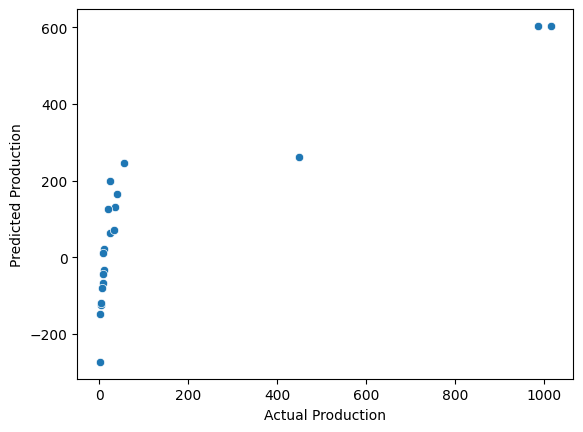

In [ ]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.show()